In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import math


In [3]:
df = pd.read_csv('Ecommerce Customers')

In [4]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [5]:
df.info() # strcuture of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [6]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


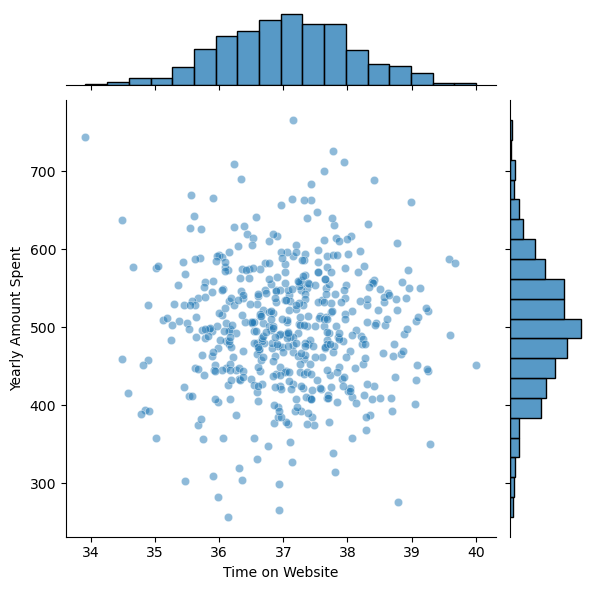

In [7]:
#EDA (Exploratory Data Analysis)
sns.jointplot(x="Time on Website", y="Yearly Amount Spent", data=df, alpha=0.5)# alpha=0.5 means that the area where they are more points, those points will be darker

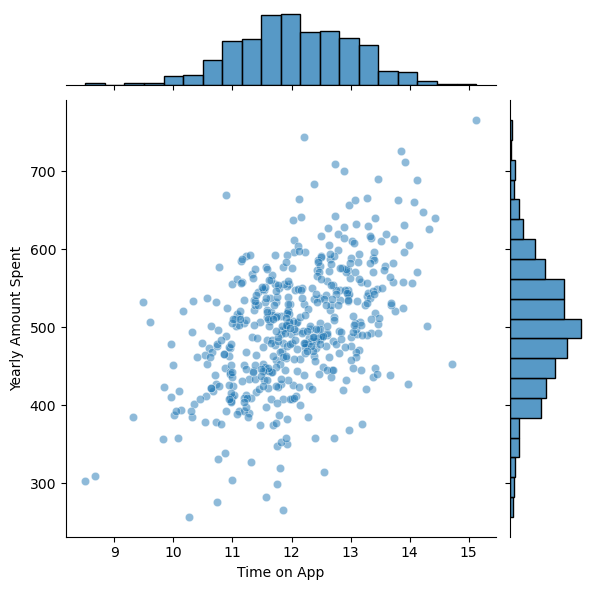

In [8]:
sns.jointplot(x="Time on App", y="Yearly Amount Spent", data=df, alpha=0.5)

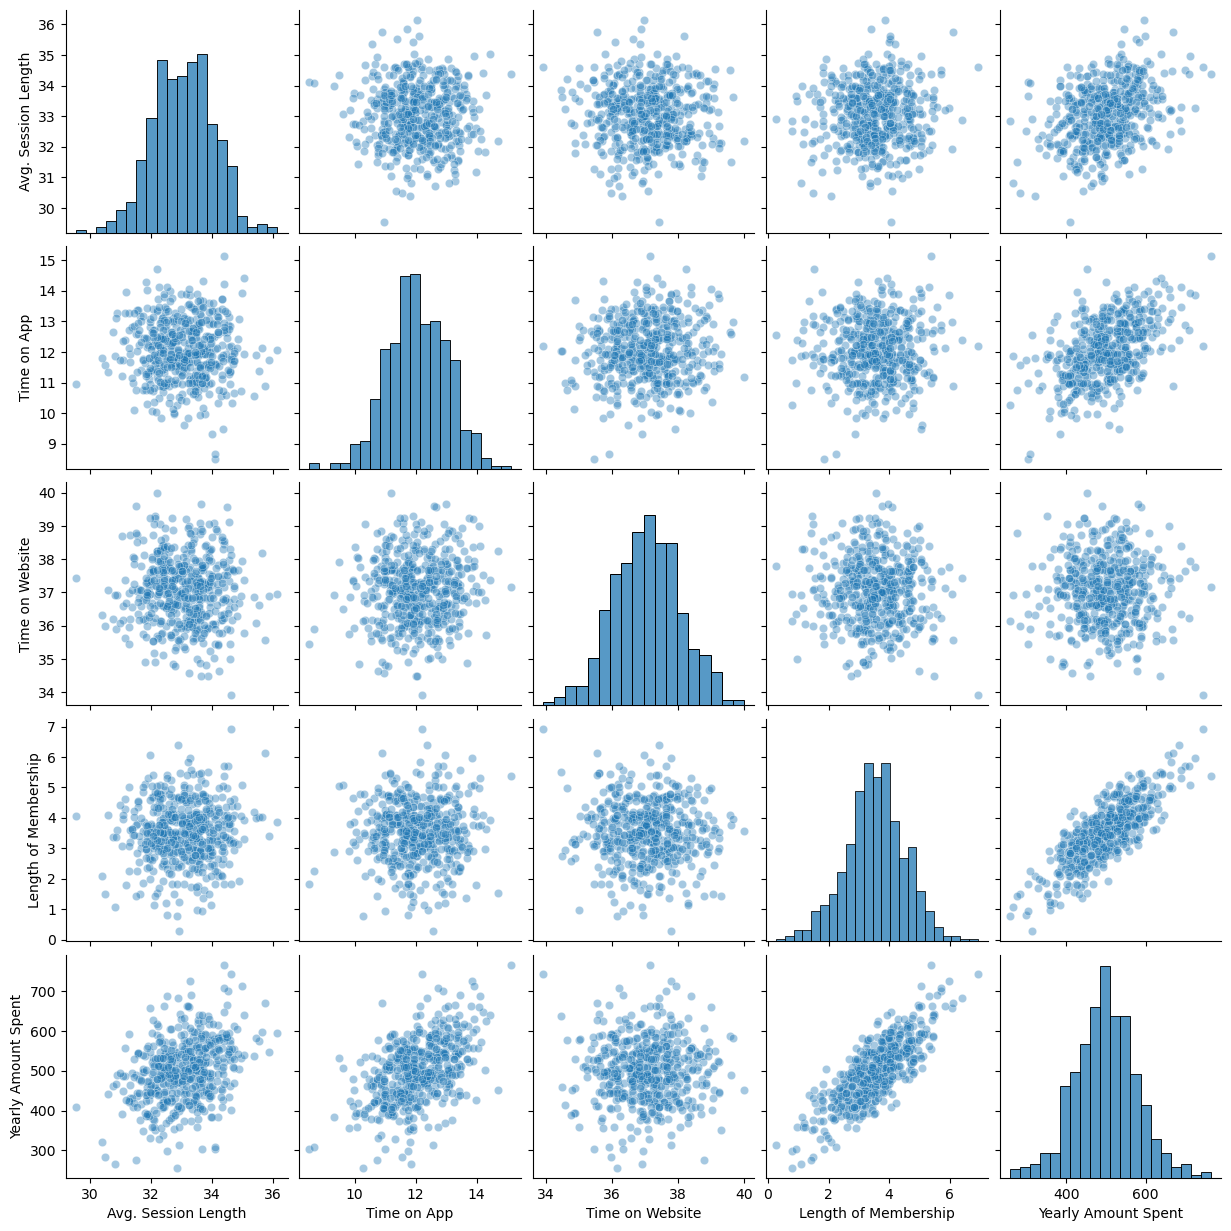

In [9]:
sns.pairplot(df, kind='scatter', plot_kws = {'alpha':0.4}) #plots all the variables against each other

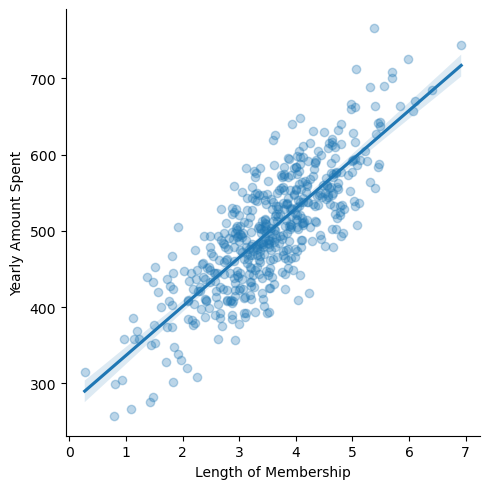

In [10]:
sns.lmplot(x='Length of Membership',
          y='Yearly Amount Spent',
          data = df,
          scatter_kws={'alpha': 0.3})

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X= df[["Avg. Session Length" ,"Time on App", "Time on Website","Length of Membership"]]
y = df["Yearly Amount Spent"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
print(y_train)
print(X_train)

5      637.102448
116    479.231093
45     549.860590
16     457.847696
462    397.420584
          ...    
106    494.551861
270    540.995739
348    392.810345
435    571.216005
102    420.737673
Name: Yearly Amount Spent, Length: 350, dtype: float64
     Avg. Session Length  Time on App  Time on Website  Length of Membership
5              33.871038    12.026925        34.476878              5.493507
116            33.925795    12.011022        36.701052              2.753424
45             34.555768    12.170525        39.131097              3.663105
16             32.125387    11.733862        34.894093              3.136133
462            33.503810    11.233415        37.211153              2.320550
..                   ...          ...              ...                   ...
106            32.291756    12.190474        36.152462              3.781823
270            34.006489    12.956277        38.655095              3.275734
348            31.812483    10.886921        34.897828

# Linear Regression (manual way)

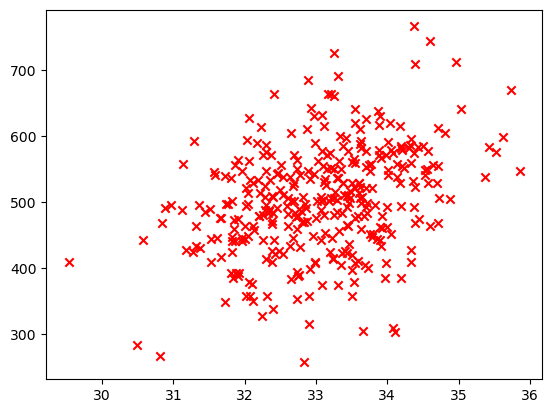

In [15]:
# Plot the data points
plt.scatter(X_train.iloc[:, 0], y_train, marker='x', c='r') # as X-train is 2D (also called DataFrame) we used .iloc and y_train is 1D so we didnt use iloc. this is a plot for the first X_train column against y





In [16]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


In [17]:
def predict(x, w, b): 
    """
    single predict using linear regression
    Args:
      x (ndarray): Shape (n,) example with multiple features
      w (ndarray): Shape (n,) model parameters   
      b (scalar):             model parameter 
      
    Returns:
      p (scalar):  prediction
    """
    p = np.dot(x, w) + b     
    return p    

In [18]:
x_vec = X_train[0:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict(x_vec,w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (350, 4), x_vec value:      Avg. Session Length  Time on App  Time on Website  Length of Membership
5              33.871038    12.026925        34.476878              5.493507
116            33.925795    12.011022        36.701052              2.753424
45             34.555768    12.170525        39.131097              3.663105
16             32.125387    11.733862        34.894093              3.136133
462            33.503810    11.233415        37.211153              2.320550
..                   ...          ...              ...                   ...
106            32.291756    12.190474        36.152462              3.781823
270            34.006489    12.956277        38.655095              3.275734
348            31.812483    10.886921        34.897828              3.128639
435            32.259973    14.132893        37.023479              3.762070
102            32.425697    11.448902        37.580190              2.586968

[350 rows x 4 columns]
f_wb shape (350,)

In [19]:
def compute_cost(X, y, w, b): #wont work here as X_train has 350 rows, while w has only 4 values
    """
    compute cost
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):                                
        f_wb_i = np.dot(X.iloc[i], w) + b       #(n,)(n,) = scalar (see np.dot)
        cost = cost + (f_wb_i - y.iloc[i])**2           
    cost = cost / (2 * m)                      #scalar    
    return cost


In [20]:
def compute_gradient(X, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar):       The gradient of the cost w.r.t. the parameter b. 
    """
    m,n = X.shape           #(number of examples, number of features)
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):                             
        err = (np.dot(X.iloc[i], w) + b) - y.iloc[i]    
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + err * X.iloc[i, j]    
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
        
    return dj_db, dj_dw

In [21]:
#Compute and display gradient 
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -1546.829320385782
dj_dw at initial w,b: 
 [-51167.19726741 -18665.21552383 -57279.49613973  -5624.03127745]


In [22]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X (ndarray (m,n))   : Data, m examples with n features
      y (ndarray (m,))    : target values
      w_in (ndarray (n,)) : initial model parameters  
      b_in (scalar)       : initial model parameter
      cost_function       : function to compute cost
      gradient_function   : function to compute the gradient
      alpha (float)       : Learning rate
      num_iters (int)     : number of iterations to run gradient descent
      
    Returns:
      w (ndarray (n,)) : Updated values of parameters 
      b (scalar)       : Updated value of parameter 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db,dj_dw = gradient_function(X, y, w, b)   ##None

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               ##None
        b = b - alpha * dj_db               ##None
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(X, y, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")
        
    return w, b, J_history #return final w,b and J history for graphing

In [23]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# some gradient descent settings
iterations = 1000
alpha = 5.0e-7
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    prediction = np.dot(X_train.iloc[i], w_final) + b_final
    target = y_train.iloc[i]
    print(f"prediction: {prediction:0.2f}, target value: {target}")

Iteration    0: Cost 129158.78   
Iteration  100: Cost 100054.60   
Iteration  200: Cost 77666.02   
Iteration  300: Cost 60443.43   
Iteration  400: Cost 47194.82   
Iteration  500: Cost 37003.19   
Iteration  600: Cost 29163.17   
Iteration  700: Cost 23132.14   
Iteration  800: Cost 18492.67   
Iteration  900: Cost 14923.66   
b,w found by gradient descent: 0.14,[4.63773646 1.70606119 5.17475408 0.53400931] 
prediction: 359.09, target value: 637.102447915074
prediction: 369.36, target value: 479.23109291159307
prediction: 385.61, target value: 549.860590464497
prediction: 351.39, target value: 457.84769594494855
prediction: 368.48, target value: 397.420584096457
prediction: 373.54, target value: 461.62827839108616
prediction: 374.33, target value: 581.8523440352178
prediction: 365.42, target value: 420.91615953269286
prediction: 368.23, target value: 508.7357409506604
prediction: 377.97, target value: 616.8515229667128
prediction: 363.54, target value: 459.285123462352
prediction: 3

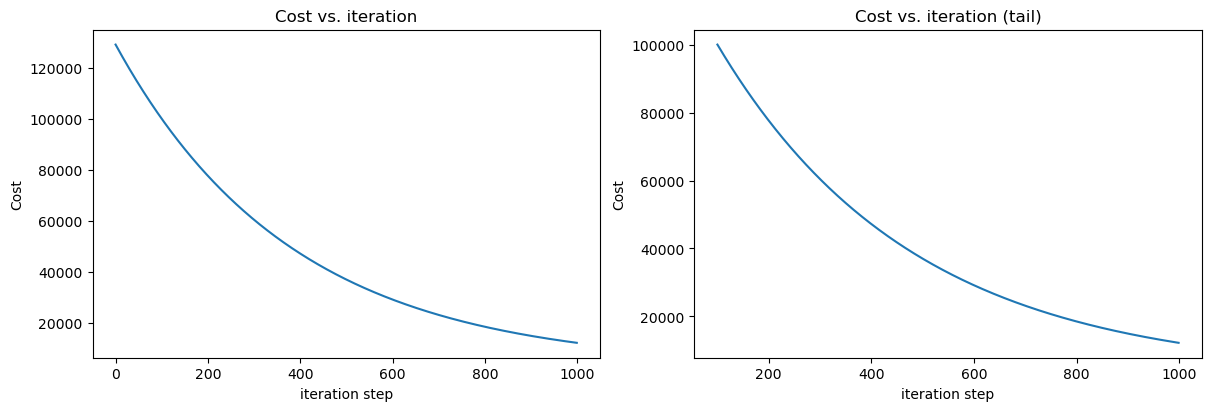

In [24]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

In [25]:
#Normalize features
def zscore_normalize_features(X):
    """
    computes  X, zcore normalized by column
    
    Args:
      X (ndarray (m,n))     : input data, m examples, n features
      
    Returns:
      X_norm (ndarray (m,n)): input normalized by column
      mu (ndarray (n,))     : mean of each feature
      sigma (ndarray (n,))  : standard deviation of each feature
    """
    # find the mean of each column/feature
    mu     = np.mean(X, axis=0)                 # mu will have shape (n,)
    # find the standard deviation of each column/feature
    sigma  = np.std(X, axis=0)                  # sigma will have shape (n,)
    # element-wise, subtract mu for that column from each example, divide by std for that column
    X_norm = (X - mu) / sigma      

    return (X_norm, mu, sigma)
 
#check our work
#from sklearn.preprocessing import scale
#scale(X_orig, axis=0, with_mean=True, with_std=True, copy=True)

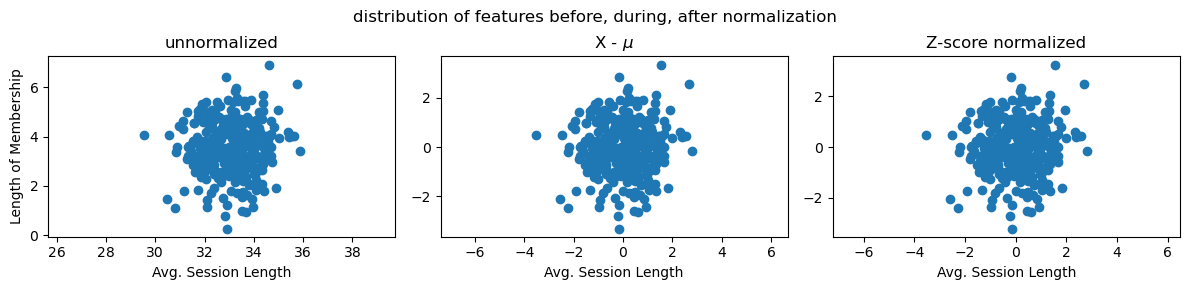

In [26]:
mu     = np.mean(X_train,axis=0)   
sigma  = np.std(X_train,axis=0) 
X_mean = (X_train - mu)
X_norm = (X_train - mu)/sigma      

fig,ax=plt.subplots(1, 3, figsize=(12, 3))
ax[0].scatter(X_train.values[:,0], X_train.values[:,3])
ax[0].set_xlabel(X_train.columns[0]); ax[0].set_ylabel(X_train.columns[3]);
ax[0].set_title("unnormalized")
ax[0].axis('equal')

ax[1].scatter(X_mean.values[:,0], X_mean.values[:,3])
ax[1].set_xlabel(X_train.columns[0]); ax[0].set_ylabel(X_train.columns[3]);
ax[1].set_title(r"X - $\mu$")
ax[1].axis('equal')

ax[2].scatter(X_norm.values[:,0], X_norm.values[:,3])
ax[2].set_xlabel(X_train.columns[0]); ax[0].set_ylabel(X_train.columns[3]);
ax[2].set_title(r"Z-score normalized")
ax[2].axis('equal')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("distribution of features before, during, after normalization")
plt.show()


In [27]:
# normalize the original features
X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)
print(f"X_mu = {X_mu}, \nX_sigma = {X_sigma}")
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

X_mu = Avg. Session Length     33.060210
Time on App             12.048784
Time on Website         36.995015
Length of Membership     3.575777
dtype: float64, 
X_sigma = Avg. Session Length     0.990043
Time on App             1.003785
Time on Website         1.020473
Length of Membership    1.027219
dtype: float64
Peak to Peak range by column in Raw        X:Avg. Session Length     6.327808
Time on App             6.618842
Time on Website         5.758744
Length of Membership    6.652788
dtype: float64
Peak to Peak range by column in Normalized X:Avg. Session Length     6.391449
Time on App             6.593881
Time on Website         5.643211
Length of Membership    6.476503
dtype: float64


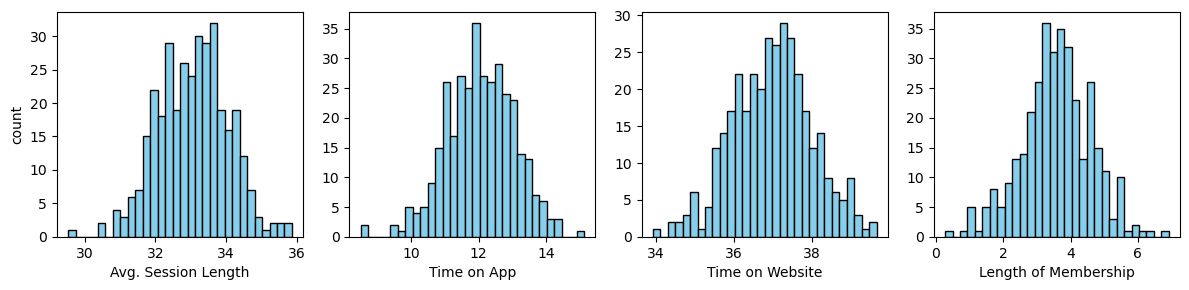

In [28]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(len(ax)):
    ax[i].hist(X_train.iloc[:, i], bins=30, color='skyblue', edgecolor='black')
    ax[i].set_xlabel(X_train.columns[i])
ax[0].set_ylabel("count")
plt.tight_layout()
plt.show()


In [32]:
def run_gradient_descent(X, y, iterations, alpha):
    w = np.zeros(X.shape[1])
    b = 0
    J_history = []

    print(f"{'Iteration':>10} {'Cost':>12} " + ''.join([f"w{i:>9}" for i in range(X.shape[1])]) + f"{'b':>9}" + ''.join([f"djdw{i:>9}" for i in range(X.shape[1])]) + f"{'djdb':>9}")
    print('-'*120)

    for i in range(iterations):
        dj_db, dj_dw = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Compute cost
        m = X.shape[0]
        cost = (1/(2*m)) * np.sum((X @ w + b - y)**2)
        J_history.append(cost)

        if i % 100 == 0:
            print(f"{i:10d} {cost:12.5e} " + ' '.join([f"{val:9.2e}" for val in w]) + f"{b:9.2e}" +
                  ' '.join([f"{val:9.2e}" for val in dj_dw]) + f"{dj_db:9.2e}")

    print(f"\nw,b found by gradient descent: w: {np.round(w, 2)}, b: {b:.2f}")
    return w, b, J_history



In [33]:
 w_norm, b_norm, hist = run_gradient_descent(X_norm, y_train, 1000, 1.0e-1, )

 Iteration         Cost w        0w        1w        2w        3        bdjdw        0djdw        1djdw        2djdw        3     djdb
------------------------------------------------------------------------------------------------------------------------
         0  1.04863e+05  2.78e+00  4.18e+00  1.09e-01  6.60e+00 5.02e+01-2.78e+01 -4.18e+01 -1.09e+00 -6.60e+01-5.02e+02
       100  4.82185e+01  2.55e+01  3.87e+01  4.69e-01  6.34e+01 5.02e+02-1.55e-04 -3.63e-04 -7.21e-06 -1.21e-03-1.33e-02
       200  4.82185e+01  2.55e+01  3.87e+01  4.69e-01  6.34e+01 5.02e+02 8.91e-09  9.98e-09 -1.19e-08 -3.44e-08-3.54e-07
       300  4.82185e+01  2.55e+01  3.87e+01  4.69e-01  6.34e+01 5.02e+02 7.92e-13  1.41e-12 -1.36e-12 -1.76e-12-9.48e-12
       400  4.82185e+01  2.55e+01  3.87e+01  4.69e-01  6.34e+01 5.02e+02 1.68e-14  3.01e-14 -2.08e-16 -3.05e-14-2.69e-13
       500  4.82185e+01  2.55e+01  3.87e+01  4.69e-01  6.34e+01 5.02e+02 1.68e-14  3.01e-14 -2.08e-16 -3.05e-14-2.69e-13
       600  4.8218

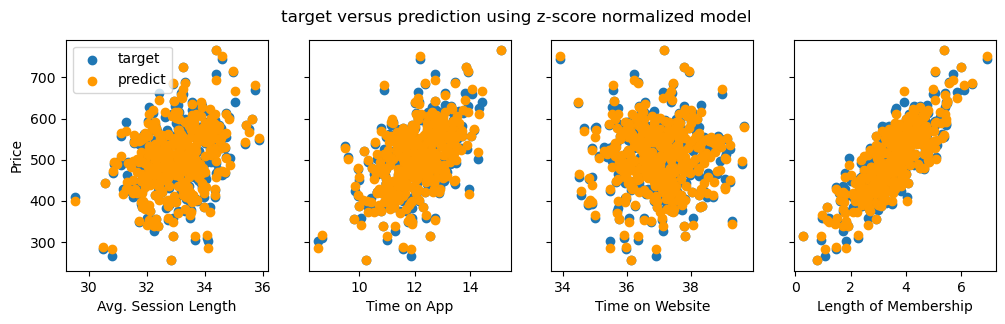

In [36]:
#predict target using normalized features
dlc = {"dlorange": "#FF9900"}  # or use any color you like
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_norm.iloc[i], w_norm) + b_norm

fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train.iloc[:, i], y_train, label='target')
    ax[i].scatter(X_train.iloc[:, i], yp, color=dlc["dlorange"], label='predict')
    ax[i].set_xlabel(X_train.columns[i])
ax[0].set_ylabel("Price")
ax[0].legend()
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()


# Linear Reg(actual way)

In [15]:
#training the model
from sklearn.linear_model import LinearRegression

In [16]:
lm = LinearRegression()

In [17]:
lm.fit(X_train, y_train)

LinearRegression()

In [18]:
lm.coef_ #the w values of all the features in the equation w1x1 + w2x2 + w3x3 + w4x4 + b

array([25.72425621, 38.59713548,  0.45914788, 61.67473243])

In [19]:
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coef'])
print(cdf)                                                #shows the w values of all the x(columns)

                           Coef
Avg. Session Length   25.724256
Time on App           38.597135
Time on Website        0.459148
Length of Membership  61.674732


In [20]:
# predictions
predictions = lm.predict(X_test)
predictions

array([403.66993069, 542.57756289, 427.06591658, 502.02460425,
       410.12143559, 569.93442508, 531.93431341, 506.29650969,
       408.71870658, 473.97737105, 441.46912726, 425.33703059,
       425.1297229 , 527.61676714, 431.45684016, 424.0769184 ,
       575.76543296, 484.89856554, 458.35936863, 481.96502182,
       502.32441491, 513.63783554, 507.58877002, 646.57464283,
       450.24372141, 496.27043415, 556.40457807, 554.95630839,
       399.64237199, 325.84623136, 532.89783259, 478.12238702,
       501.05701845, 305.97335848, 505.77244448, 483.79591969,
       518.8331528 , 438.18241857, 456.71094234, 471.04609461,
       494.44008972, 445.31155755, 508.78802753, 501.04594193,
       488.83499673, 535.38079541, 595.20129802, 514.04714872,
       280.76758312, 433.10112367, 421.70823427, 481.23640152,
       584.71372272, 608.7748096 , 563.98513427, 494.72804869,
       394.52133407, 456.4197529 , 573.08767515, 499.6984241 ,
       512.83277025, 392.12434043, 480.05057697, 481.54

Text(0.5, 1.0, 'Evaluation of our LM model')

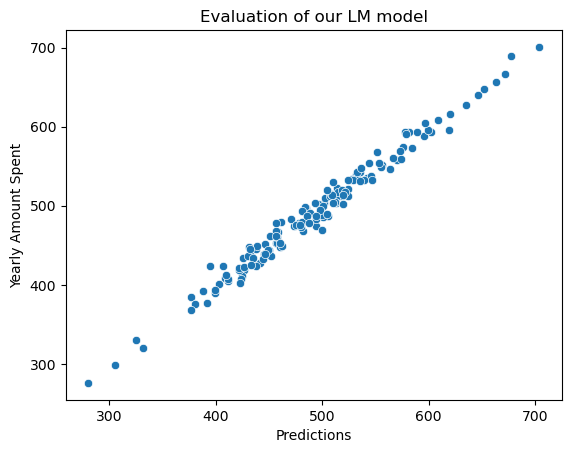

In [21]:
sns.scatterplot(x=predictions, y=y_test) # we use keyword arguments here like x=predicions, as if we used positional arg like directly sns.scatterplot(predictions, y_test), we would ve gotten an error
plt.xlabel("Predictions")
plt.title("Evaluation of our LM model")# LM = Linear Regression

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [23]:
print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("Mean Squared Error:", mean_squared_error(y_test, predictions))
print("Root Mean Squared Error(RMSE):", math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error: 8.426091641432128
Mean Squared Error: 103.91554136503363
Root Mean Squared Error(RMSE): 10.193897260863169


In [24]:
# Residuals

In [25]:
residuals = y_test - predictions

In [26]:
residuals # here 361 was the actual value and -2 was the difference between the predicted value and the actual value
          # basically the residual value should be random, they shudnt have a correlation, if they do, it means something is sketchy

361    -2.636795
73     -7.800375
374    -8.463174
155     1.953775
104    -0.051825
         ...    
266    10.327176
23     15.027984
222   -16.778237
261    -6.021734
426    -4.371832
Name: Yearly Amount Spent, Length: 150, dtype: float64

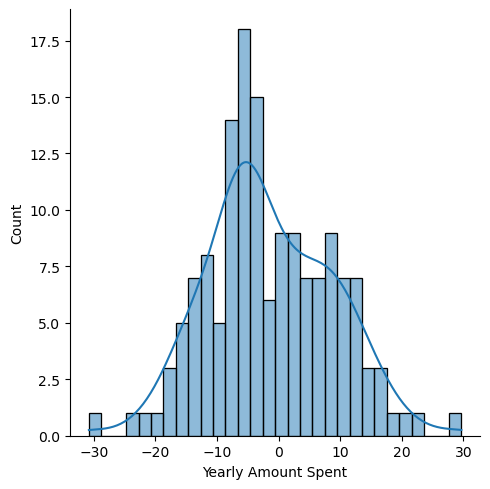

In [27]:
sns.displot(residuals, bins=30, kde=True) # bins mean how many bars we want, we can even just use sns.displot(residuals) directly
                                          #kde= true adds that curve line on the bars

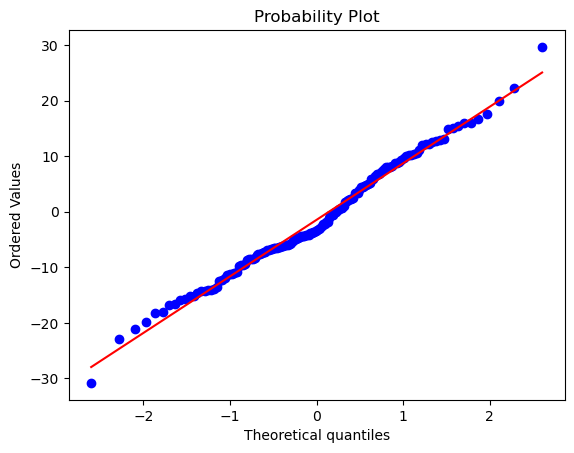

In [28]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()
# this plot is called a Q-Q plot, it has normmality on one side and residuals on the other side
# if this plot is a straight line it means ur residuals are normally distributed 